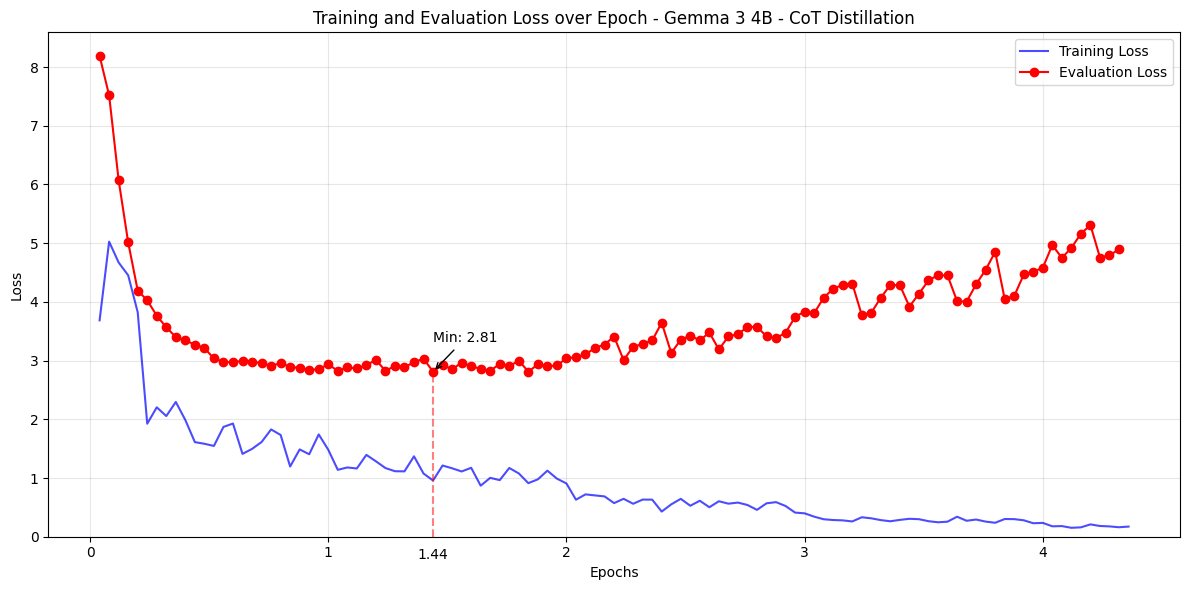

In [11]:
import json
import matplotlib.pyplot as plt

# Read the data from jsonl file
data = []
with open('./gemma-runs-loss/cotv2-loss.jsonl', 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Extract training and evaluation data
train_epochs = []
train_losses = []
eval_epochs = []
eval_losses = []

for entry in data:
    if 'loss' in entry and 'epoch' in entry:
        train_epochs.append(entry['epoch'])
        train_losses.append(entry['loss'])
    elif 'eval_loss' in entry and 'epoch' in entry:
        eval_epochs.append(entry['epoch'])
        eval_losses.append(entry['eval_loss'])

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(train_epochs, train_losses, 'b-', label='Training Loss', alpha=0.7)
plt.plot(eval_epochs, eval_losses, 'r-', marker='o', label='Evaluation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss over Epoch - Gemma 3 4B - CoT Distillation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)  # Start y-axis at 0

# Add annotations for min/max values
# min_train_loss = min(train_losses)
# min_train_epoch = train_epochs[train_losses.index(min_train_loss)]
# plt.annotate(f'Min: {min_train_loss:.2f}', 
#              xy=(min_train_epoch, min_train_loss),
#              xytext=(min_train_epoch, min_train_loss+0.5),
#              arrowprops=dict(arrowstyle='->'))

# min eval loss
min_eval_loss = min(eval_losses)
min_eval_epoch = eval_epochs[eval_losses.index(min_eval_loss)]
plt.annotate(f'Min: {min_eval_loss:.2f}', 
             xy=(min_eval_epoch, min_eval_loss),
             xytext=(min_eval_epoch, min_eval_loss+0.5),
             arrowprops=dict(arrowstyle='->'))

# Mark the x-axis for min eval loss
plt.axvline(x=min_eval_epoch, color='r', linestyle='--', alpha=0.5, ymax=min_eval_loss/plt.ylim()[1])
plt.text(min_eval_epoch, -0.2, f'{min_eval_epoch:.2f}', 
         horizontalalignment='center', verticalalignment='top')

# Save and show plot
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=300)
plt.show()

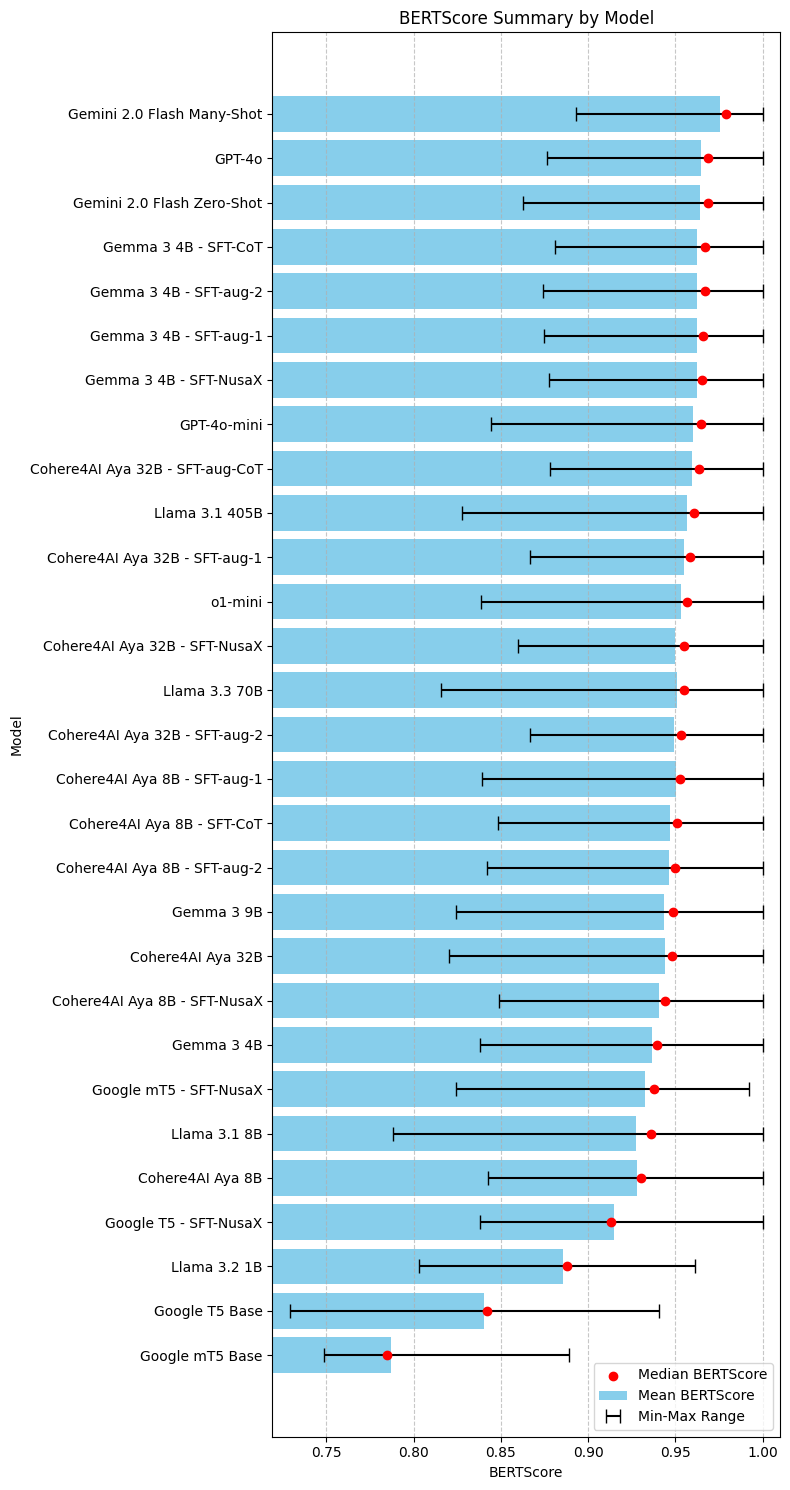

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read data from the CSV file
df = pd.read_csv('bertscore_summary_cleaned.csv')

# Extract model names from filenames by removing the prefix and suffix
# df['model_name'] = df['file'].str.replace('translation_results_', '').str.replace('.csv', '')
df['model_name'] = df['name']
# Sort by avg_bertscore in ascending order (to reverse the order of bars)
df_sorted = df.sort_values('median_bertscore', ascending=True)

# Extract data for plotting
models = df_sorted['model_name'].tolist()
avg_bertscore = df_sorted['avg_bertscore'].tolist()
median_bertscore = df_sorted['median_bertscore'].tolist()
min_bertscore = df_sorted['min_bertscore'].tolist()
max_bertscore = df_sorted['max_bertscore'].tolist()

# Plotting - make it vertical by swapping x and y axes
plt.figure(figsize=(8, 15))
bars = plt.barh(models, avg_bertscore, color='skyblue', label='Mean BERTScore')
plt.errorbar(avg_bertscore, models, xerr=[np.subtract(avg_bertscore, min_bertscore), np.subtract(max_bertscore, avg_bertscore)], 
             fmt='none', ecolor='black', capsize=5, label='Min-Max Range')
plt.scatter(median_bertscore, models, color='red', zorder=5, label='Median BERTScore')

# Customize
plt.yticks(rotation=0)
plt.ylabel('Model')
plt.xlabel('BERTScore')
plt.title('BERTScore Summary by Model', ha='center')
plt.legend()

# Set tighter x-axis limits
min_x = min(min_bertscore) - 0.01  # Add a small margin
max_x = max(max_bertscore) + 0.01
plt.xlim(min_x, max_x)

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

# Show plot
plt.show()

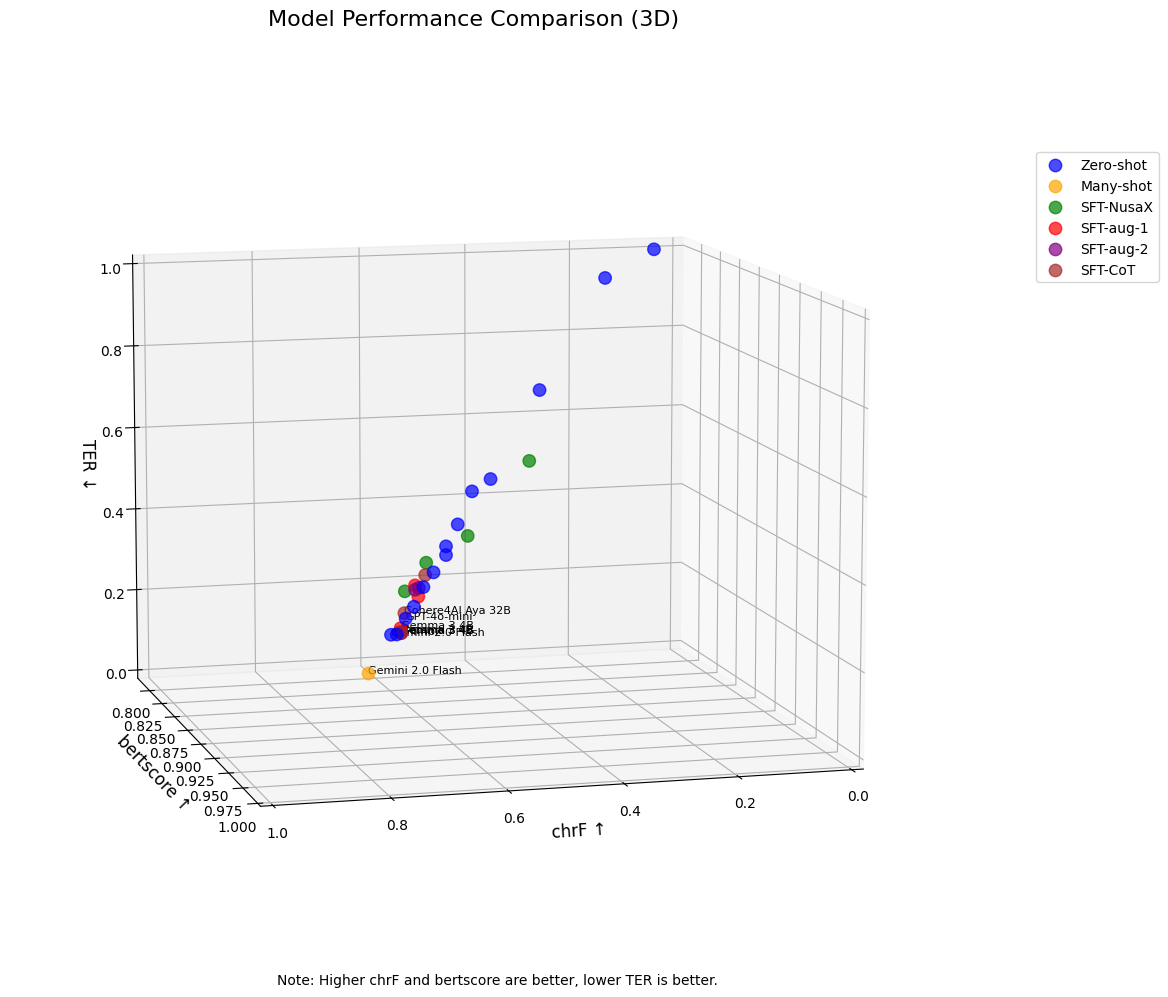

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

# Data model
modelData = { 
    'Zero-shot': [
        { 'name': 'Gemini 2.0 Flash', 'chrF': 0.76, 'bertscore': 0.969, 'TER': 0.30, 'size': 100 },
        { 'name': 'GPT-4o', 'chrF': 0.75, 'bertscore': 0.969, 'TER': 0.30, 'size': 100 },
        { 'name': 'GPT-4o-mini', 'chrF': 0.73, 'bertscore': 0.965, 'TER': 0.33, 'size': 100 },
        { 'name': 'Llama 3.1 405B', 'chrF': 0.71, 'bertscore': 0.960, 'TER': 0.35, 'size': 100 },
        { 'name': 'o1-mini', 'chrF': 0.69, 'bertscore': 0.957, 'TER': 0.39, 'size': 100 },
        { 'name': 'Llama 3.3 70B', 'chrF': 0.67, 'bertscore': 0.955, 'TER': 0.42, 'size': 100 },
        { 'name': 'Gemma 9B', 'chrF': 0.64, 'bertscore': 0.948, 'TER': 0.45, 'size': 100 },
        { 'name': 'Cohere4AI Aya 32B', 'chrF': 0.64, 'bertscore': 0.948, 'TER': 0.47, 'size': 100 },
        { 'name': 'Gemma 3 4B', 'chrF': 0.61, 'bertscore': 0.940, 'TER': 0.51, 'size': 100 },
        { 'name': 'Llama 3.1 8B', 'chrF': 0.58, 'bertscore': 0.936, 'TER': 0.58, 'size': 100 },
        { 'name': 'Cohere4AI Aya 8B', 'chrF': 0.54, 'bertscore': 0.930, 'TER': 0.60, 'size': 100 },
        { 'name': 'Llama 3.2 1B', 'chrF': 0.40, 'bertscore': 0.888, 'TER': 0.76, 'size': 100 },
        { 'name': 't5-base', 'chrF': 0.22, 'bertscore': 0.842, 'TER': 0.98, 'size': 100 },
        { 'name': 'mt5-base', 'chrF': 0.05, 'bertscore': 0.785, 'TER': 1.00, 'size': 100 }
    ],
    'Many-shot': [
        { 'name': 'Gemini 2.0 Flash', 'chrF': 0.81, 'bertscore': 0.979, 'TER': 0.23, 'size': 100 }
    ],
    'SFT-NusaX': [
        { 'name': 'Cohere4AI Aya 32B', 'chrF': 0.72, 'bertscore': 0.955, 'TER': 0.38, 'size': 100 },
        { 'name': 'Gemma 3 4B', 'chrF': 0.74, 'bertscore': 0.965, 'TER': 0.30, 'size': 100 },
        { 'name': 'Cohere4AI Aya 8B', 'chrF': 0.67, 'bertscore': 0.944, 'TER': 0.43, 'size': 100 },
        { 'name': 't5-base', 'chrF': 0.45, 'bertscore': 0.913, 'TER': 0.62, 'size': 100 },
        { 'name': 'mt5-base', 'chrF': 0.59, 'bertscore': 0.938, 'TER': 0.48, 'size': 100 }
    ],
    'SFT-aug-1': [
        { 'name': 'Cohere4AI Aya 32B', 'chrF': 0.70, 'bertscore': 0.958, 'TER': 0.37, 'size': 100 },
        { 'name': 'Gemma 3 4B', 'chrF': 0.74, 'bertscore': 0.966, 'TER': 0.31, 'size': 100 },
        { 'name': 'Cohere4AI Aya 8B', 'chrF': 0.70, 'bertscore': 0.953, 'TER': 0.39, 'size': 100 }
    ],
    'SFT-aug-2': [
        { 'name': 'Cohere4AI Aya 32B', 'chrF': 0.70, 'bertscore': 0.953, 'TER': 0.38, 'size': 100 },
        { 'name': 'Gemma 3 4B', 'chrF': 0.74, 'bertscore': 0.967, 'TER': 0.30, 'size': 100 },
        { 'name': 'Cohere4AI Aya 8B', 'chrF': 0.69, 'bertscore': 0.950, 'TER': 0.38, 'size': 100 }
    ],
    'SFT-CoT': [
        { 'name': 'Cohere4AI Aya 32B', 'chrF': 0.73, 'bertscore': 0.963, 'TER': 0.34, 'size': 100 },
        { 'name': 'Gemma 3 4B', 'chrF': 0.74, 'bertscore': 0.967, 'TER': 0.30, 'size': 100 },
        { 'name': 'Cohere4AI Aya 8B', 'chrF': 0.68, 'bertscore': 0.951, 'TER': 0.41, 'size': 100 }
    ]
}

# Convert to dataframe format with category column
data = []
for category, models in modelData.items():
    for model in models:
        model_copy = model.copy()
        model_copy['category'] = category
        data.append(model_copy)
        
df = pd.DataFrame(data)

# Setup the figure and 3D axis
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors for each category
colors = {
    'Zero-shot': 'blue',
    'Many-shot': 'orange',
    'SFT-NusaX': 'green',
    'SFT-aug-1': 'red',
    'SFT-aug-2': 'purple',
    'SFT-CoT': 'brown'
}

# Create the 3D scatter plot
for category, color in colors.items():
    category_data = df[df['category'] == category]
    ax.scatter(
        category_data['chrF'], 
        category_data['bertscore'], 
        category_data['TER'],
        s=80, 
        c=color, 
        label=category,
        alpha=0.7
    )

# Add labels for top-performing models
for i, row in df.iterrows():
    # Only label certain models to avoid overcrowding
    if ((row['chrF'] > 0.7 and row['bertscore'] > 0.95 and row['TER'] < 0.35) or
        (row['category'] == 'Many-shot')):
        ax.text(row['chrF'], row['bertscore'], row['TER'], row['name'], size=8)

# Set axis labels and limits
ax.set_xlabel('chrF ↑', fontsize=12)
ax.set_ylabel('bertscore ↑', fontsize=12)
ax.set_zlabel('TER ↓', fontsize=12)

ax.set_xlim(0, 1)
ax.set_ylim(0.78, 1)
ax.set_zlim(0, 1)

# Add a title and legend
ax.set_title('Model Performance Comparison (3D)', fontsize=16, pad=20)
ax.legend(loc='upper left', bbox_to_anchor=(1.1, 0.9))

# Add a note about metrics
plt.figtext(0.5, 0.01, 
           "Note: Higher chrF and bertscore are better, lower TER is better.",
           ha='center', fontsize=10)

# Adjust view angle for better visibility
ax.view_init(elev=10, azim=75)

# Add grid lines
ax.grid(True)

plt.tight_layout()
plt.show()